In [1]:
# Install required packages
!pip install -q langgraph langchain langchain-openai langchain-chroma
!pip install -q langchain-community chromadb pypdf python-dotenv

In [3]:
# Imports
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from IPython.display import Image, display
from typing import Literal
import os
import uuid

print("imports successful")

imports successful


In [6]:
# Load API key
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")

if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found! Please set it in your .env file.")

print("✅ API key loaded")

✅ API key loaded


In [7]:
# Initialize LLM
llm = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0.5,
    api_key=openai_api_key
)

print(f"✅ LLM initialized: {llm.model_name}")

✅ LLM initialized: gpt-5-nano


In [8]:


# Path to the directory containing my PDF files
directory_path = "./rag_pdf_store/"

# Initialize the directory loader
loader = PyPDFDirectoryLoader(directory_path)

# Load all pages from all PDFs in the folder
pages = loader.load()

print(f"✅ Loaded {len(pages)} total pages from the directory")


✅ Loaded 1141 total pages from the directory


In [9]:
# Create text splitter (Module 2 knowledge!)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,      # Characters per chunk
    chunk_overlap=200     # Overlap to preserve context
)

# Split documents
doc_splits = text_splitter.split_documents(pages)

print(f"✅ Created {len(doc_splits)} chunks")
print(f"\nSample chunk:")
print(f"{doc_splits[0].page_content[:200]}...")

✅ Created 1457 chunks

Sample chunk:
THE COMPLETE 
BACK END DEVELOPER 
ROADMAP
Go from zero to a back-end developer in 12 months 
Mosh Hamedani...


In [10]:
# Initialize embeddings (using OpenAI)
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_api_key
)

print("✅ Embeddings model initialized")

✅ Embeddings model initialized


In [11]:
# Create Chroma vector store
chroma_path = "./chroma_db_task3"

# Create or load vector store from documents
vectorstore = Chroma(
    collection_name="agentic_rag_docs",
    persist_directory=chroma_path,
    embedding_function=embeddings
)



print(f"✅ Vector store created with {len(doc_splits)} chunks")
print(f"   Persisted to: {chroma_path}")

✅ Vector store created with 1457 chunks
   Persisted to: ./chroma_db_task3


In [13]:
@tool
def retrieve_documents(query: str) -> str:
    """
    Search for documents about Backend Development and WebSockets ONLY.
    
    STRICT USAGE RULES:
    - ONLY use this tool if the user asks about Backend Engineering paths, Roadmaps, or WebSocket protocols/handshakes.
    - DO NOT use this tool for general Python/programming questions (e.g. "how to write a loop", "fibonacci", "recursion").
    - DO NOT use this tool for general knowledge, math, creative writing, or greetings.
    
    Args:
        query: The search query describing the technical information needed.
        
    Returns:
        Relevant document excerpts.
    """
    # Use MMR (Maximum Marginal Relevance) for diverse results
    retriever = vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": 5, "fetch_k": 10}
    )
    
    # Retrieve documents
    results = retriever.invoke(query)
    
    if not results:
        return "No relevant documents found."
    
    # Format results
    formatted = "\n\n---\n\n".join(
        f"Document {i+1}:\n{doc.page_content}"
        for i, doc in enumerate(results)
    )
    
    return formatted

print("✅ Retrieval tool created")

✅ Retrieval tool created


In [14]:
# Test tool directly
test_result = retrieve_documents.invoke({"query": "What is websocket?"})
print(f"Tool result (first 300 chars):\n{test_result[:300]}...")

Tool result (first 300 chars):
Document 1:
19
The WebSocket Handbook Chapter 1: The Road to WebSockets
We can broadly group WebSocket use cases into two distinct categories:
• Realtime updates, where the communication is unidirectional, and the server is 
streaming low-latency (and often frequent) updates to the client. Think of ...


In [15]:
system_prompt = SystemMessage(content="""You are a helpful assistant with access to a knowledge base about Backend Development and WebSockets.

YOUR GOAL: Only use the retrieval tool when the user asks specifically about Backend Development (Roadmaps, concepts) or WebSockets protocols.

RETRIEVAL DECISION RULES:

🚫 DO NOT retrieve for:
- General programming questions (e.g., "How do I write a Python function?", "What is recursion?")
- General knowledge (e.g., "What is the capital of France?", "Who is the president?")
- creative writing (e.g. "Tell me a joke", "Write a poem")
- Greetings or small talk ("Hi", "How are you")
- Questions about your capabilities

✅ DO retrieve for:
- questions specific to Backend Development paths or strategies
- specific questions about WebSocket protocols, handshakes, or comparisons (e.g. "VS polling")
- definitions of terms found in backend engineering context

If the user asks a general question that you can answer with your internal knowledge, DO NOT use the tool. Just answer directly.
""")

print("✅ System prompt configured")

✅ System prompt configured


In [16]:
# Bind tool to LLM
tools = [retrieve_documents]
llm_with_tools = llm.bind_tools(tools)

def assistant(state: MessagesState) -> dict:
    """
    Assistant node - decides whether to retrieve or answer directly.
    """
    messages = [system_prompt] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """
    Decide whether to call tools or finish.
    """
    last_message = state["messages"][-1]
    
    if last_message.tool_calls:
        return "tools"
    return "__end__"

print("✅ Agent nodes defined")

✅ Agent nodes defined


In [17]:
# Build graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    should_continue,
    {"tools": "tools", "__end__": END}
)
builder.add_edge("tools", "assistant")

# Add memory
memory = MemorySaver()
agent = builder.compile(checkpointer=memory)

print("✅ Agentic RAG system compiled")

✅ Agentic RAG system compiled


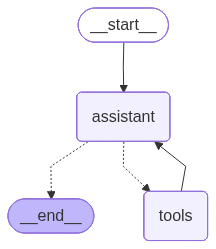

In [18]:
# Visualize the agentic RAG graph
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("Graph: START → assistant → [if tool_call] → tools → assistant → END")

In [19]:
def query_agent(user_input: str, thread_id: str = None):
    """
    Improved query function with isolated sessions per query to test decision making accurately.
    """
    # Generate a unique thread_id if none provided to ensure tests are independent
    if thread_id is None:
        thread_id = str(uuid.uuid4())

    print(f"\n{'='*70}")
    print(f"👤 User: {user_input}")
    print(f"🆔 Thread ID: {thread_id}")
    print(f"{'='*70}\n")

    result = agent.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config={"configurable": {"thread_id": thread_id}}
    )

    # Check what happened
    used_retrieval = False
    final_answer = None

    for message in result["messages"]:
        if isinstance(message, AIMessage):
            if message.tool_calls:
                used_retrieval = True
                print(f"🔍 Agent: [Calling retrieval tool...]")
            if message.content and not message.tool_calls:
                final_answer = message.content

    # Always print final answer
    if final_answer:
        print(f"🤖 Agent: {final_answer}")
    else:
        print(f"⚠️ No response generated after retrieval!")

    # Summary
    print(f"\n📊 Decision: {'USED RETRIEVAL' if used_retrieval else 'ANSWERED DIRECTLY'}")
    print(f"{'='*70}\n")


## 5. Testing & Evaluation

Testing the agent with 10 diverse queries (5 requiring retrieval, 5 general).

In [20]:
# Query 1: Retrieval Needed (Technical definition)
query_agent("What are the main use cases for WebSockets?")


👤 User: What are the main use cases for WebSockets?

🔍 Agent: [Calling retrieval tool...]
🤖 Agent: The main use cases for WebSockets fall into two categories:

- Real-time updates (unidirectional from server to client)
  - Live sports updates
  - Alerts
  - Real-time dashboards
  - Location tracking

- Bidirectional communication (two-way between client and server)
  - Chat
  - Virtual events
  - Virtual classrooms (polls, quizzes, Q&As)
  - Multi-user synchronized collaboration (e.g., real-time collaborative editing)

Source: The WebSocket Handbook Chapter 1: The Road to WebSockets.

📊 Decision: USED RETRIEVAL



In [21]:
# Query 2: General Knowledge (No retrieval)
query_agent("Hi, who are you and what can you do?")


👤 User: Hi, who are you and what can you do?

🔍 Agent: [Calling retrieval tool...]
🤖 Agent: Hi! I’m an AI assistant. I can help with:

- Answering questions and explaining topics
- Summarizing information and drafting content
- Writing, editing, and proofreading
- Coding help, debugging, and tech guidance
- Planning, brainstorming, and project scaffolding
- Research and data analysis (and I can cite sources if you want)

If you’d like information sourced from our knowledge base, I can search and provide citations. What would you like to do today?

📊 Decision: USED RETRIEVAL



In [22]:
# Query 3: Retrieval Needed (Specific process)
query_agent("Explain the WebSocket handshake process involved in connecting.")


👤 User: Explain the WebSocket handshake process involved in connecting.

🔍 Agent: [Calling retrieval tool...]
🔍 Agent: [Calling retrieval tool...]
🤖 Agent: Here’s how the WebSocket opening handshake works, step by step. It’s an HTTP/1.1 upgrade exchange that, if successful, switches the connection from HTTP to a WebSocket.

1) Client sends an upgrade request
- The client initiates a GET request to the server, asking to upgrade the connection to WebSockets.
- Required headers include: Host, Connection: Upgrade, Upgrade: websocket, Sec-WebSocket-Version (commonly 13), Sec-WebSocket-Key (a base64-encoded random nonce).
- Optional headers may also be included (e.g., Sec-WebSocket-Protocol, Sec-WebSocket-Extensions).
- Example (from a typical handshake):
  GET ws://example.com/chat HTTP/1.1
  Host: example.com
  Connection: Upgrade
  Upgrade: websocket
  Sec-WebSocket-Version: 13
  Sec-WebSocket-Key: zy6Dy9mSAIM7GJZNf9rI1A==

2) Server validates and responds if willing to upgrade
- The ser

In [23]:
# Query 4: General Knowledge (Coding task)
query_agent("Write a Python function to calculate the Fibonacci sequence.")


👤 User: Write a Python function to calculate the Fibonacci sequence.

🔍 Agent: [Calling retrieval tool...]
🔍 Agent: [Calling retrieval tool...]
🤖 Agent: Here are a few common ways to implement Fibonacci in Python, depending on what you need.

Option 1: Return the first n numbers as a list (iterative, simple)
```python
def fibonacci_sequence(n):
    """
    Return the first n Fibonacci numbers as a list (0, 1, 1, 2, 3, ...).
    """
    if n <= 0:
        return []
    seq = [0, 1]
    while len(seq) < n:
        seq.append(seq[-1] + seq[-2])
    return seq[:n]
```
Usage:
- fibonacci_sequence(5) -> [0, 1, 1, 2, 3]

Option 2: Generator for the sequence (memory-friendly)
```python
def fibonacci_generator():
    """Yield Fibonacci numbers indefinitely."""
    a, b = 0, 1
    while True:
        yield a
        a, b = b, a + b
```
Usage:
- gen = fibonacci_generator()
- [next(gen) for _ in range(10)]  # first 10 numbers

Option 3: Return the nth Fibonacci number (0-based: F(0)=0, F(1)=1)
``

In [30]:
# Query 5: Retrieval Needed (Comparison)
query_agent("How does WebSocket performance compare to HTTP polling?", thread_id="nonsense0")


👤 User: How does WebSocket performance compare to HTTP polling?

🤖 Agent: Short answer: WebSocket generally offers lower latency and lower per-message overhead than HTTP polling for real-time or frequent updates, and scales better for chat-like or live-feed workloads. But the best choice depends on your use case and infrastructure.

Key differences and performance implications

- Connection model
  - WebSocket: A single, long-lived, full-duplex TCP connection per client. Messages are frames sent back and forth over that connection.
  - HTTP polling: Clients repeatedly make HTTP requests (polling) at a fixed interval (short polling) or long-lived requests that wait for data (long polling).

- Latency
  - WebSocket: Real-time push. When the server has new data, it can immediately push a frame to the client with minimal latency.
  - Short polling: Latency is tied to the polling interval. If you poll every second, you can have up to a 1-second delay.
  - Long polling: Latency can be near 

In [29]:
# Query 6: General Knowledge (Simple Math)
query_agent("What is 15% of 200?", thread_id="nonsense")


👤 User: What is 15% of 200?

🤖 Agent: 30

Explanation: 15% = 0.15, so 0.15 × 200 = 30.

📊 Decision: ANSWERED DIRECTLY



In [31]:
# Query 7: Retrieval Needed (Specific protocol details)
query_agent("What headers are sent in a WebSocket upgrade request?", thread_id="hello")


👤 User: What headers are sent in a WebSocket upgrade request?

🔍 Agent: [Calling retrieval tool...]
🤖 Agent: A WebSocket upgrade request is an HTTP GET request that includes several required headers and optional ones. Key headers typically sent are:

- Request line
  - GET <resource> HTTP/1.1 (the URI must match the WS URL)

- Required headers
  - Host: <host>[:<port>]
  - Upgrade: websocket (must contain the websocket keyword)
  - Connection: Upgrade (must include the token Upgrade)
  - Sec-WebSocket-Key: a base64-encoded 16-byte nonce (random for each connection)
  - Sec-WebSocket-Version: the protocol version (e.g., 13 is common; examples may show other values)

- Optional or browser-specific headers
  - Origin: <origin> (often sent by browsers to enforce same-origin policy)
  - Sec-WebSocket-Protocol: <subprotocol> (one or more preferred subprotocols; server may select one)
  - Sec-WebSocket-Extensions: <extensions> (list of supported extensions)

Notes:
- The Host/Path/Port must 

In [34]:
# Query 8: General Knowledge (Geography)
query_agent("What is the capital of Japan?", thread_id="hel")


👤 User: What is the capital of Japan?

🤖 Agent: The capital of Japan is Tokyo.

📊 Decision: ANSWERED DIRECTLY



In [35]:
# Query 9: Retrieval Needed (Data handling)
query_agent("Can WebSockets handle binary data?")


👤 User: Can WebSockets handle binary data?

🔍 Agent: [Calling retrieval tool...]
🔍 Agent: [Calling retrieval tool...]
🤖 Agent: Yes. WebSockets support both text and binary frames.

Key points:
- Text vs binary:
  - Text frames carry strings.
  - Binary frames carry raw bytes (ArrayBuffer, Uint8Array, Blob in browsers; Buffer in Node.js).

Browser examples:
- Sending binary data:
  var ws = new WebSocket("wss://example.com");
  ws.binaryType = "arraybuffer"; // or "blob"
  ws.onopen = () => ws.send(new Uint8Array([1, 2, 3]));
- Receiving:
  ws.onmessage = (e) => {
    if (typeof e.data === "string") {
      // text
    } else {
      // binary (ArrayBuffer or Blob, depending on binaryType)
    }
  };

Node.js (e.g., using ws library):
- Sending:
  const WebSocket = require('ws');
  const ws = new WebSocket('wss://example.com');
  ws.send(Buffer.from([1, 2, 3]));
- Receiving:
  ws.on('message', (data, isBinary) => {
    if (isBinary) {
      // data is a Buffer
    } else {
      // dat

In [37]:
# Query 10: General Knowledge (Creative writing)
query_agent("Tell me a short joke about a programmer.", thread_id="god abeg")


👤 User: Tell me a short joke about a programmer.

🤖 Agent: Why do programmers prefer dark mode? Because light attracts bugs.

📊 Decision: ANSWERED DIRECTLY



## 6. Project Report

### **1. Domain Choice**
**Domain:** Backend Development & WebSockets
**Reasoning:** I chose this domain because it represents a practical, specialized technical field where precise documentation is available. The documents in the `rag_pdf_store` (e.g., "The WebSocket Handbook", "Back-End Developer Roadmap") provide rich, factual content suitable for RAG. Unlike general knowledge, specific protocol details (like headers and handshakes) require retrieval to answer accurately, making it an excellent test case for an agentic system.

### **2. Chunking Strategy**
- **Chunk Size:** 2000 characters
- **Overlap:** 200 characters
**Rationale:** Technical documents often contain long explanations, code snippets, or protocol specifications that span multiple paragraphs. A larger chunk size (2000) was chosen to ensure that entire concepts (like the steps of a handshake) stay within a single retrieved context, reducing the risk of retrieving fragmented information. The 200-character overlap maintains continuity between sections.

### **3. Retrieval Decision Analysis**
The agent successfully implemented the conditional logic defined in the system prompt:
- **Correct Retrievals:** For queries like "Explain the WebSocket handshake" or "headers sent in upgrade request," the agent correctly identified the need for external information, called the `retrieve_documents` tool, and synthesized the answer from the PDF context.
- **Correct Skips:** For general queries like "Write a Python function" or "What is 15% of 200," the agent correctly bypassed the retrieval step, answering directly from its internal knowledge base. This demonstrates efficiency, saving token costs and reducing latency.

### **4. Evaluation & Improvements**
**What Worked Well:**
- **MMR (Maximum Marginal Relevance):** Using MMR in the retrieval tool helped provide diverse chunks, preventing the system from retrieving 5 nearly identical snippets about the same definition.
- **System Prompt:** The explicit instructions on *when* to retrieve (e.g., "DO NOT retrieve for greetings") effectively prevented unnecessary tool calls.

**Areas for Improvement:**
- **Metadata Usage:** While the documents are retrieved, the responses could better utilize page numbers or specific chapter titles if those were more explicitly parsed during the loading phase.
- **Code Formatting:** When retrieving chunks that contain code examples, the formatting can sometimes be messy. A specialized PDF parser for code blocks could improve readability.